# 📊 Day 2 — Data Cleaning & Feature Engineering
## Nairobi House Price Prediction — 6-Day Sprint

---

**Objective:** Transform the cleaned dataset into a model-ready feature matrix.

**Tasks:**
1. ✅ Remove duplicates (already done in Day 1 cleaning)
2. ✅ Handle missing values (already done in Day 1 cleaning)
3. Standardize location names
4. Convert size units (already in m²)
5. Remove extreme outliers
6. **Feature Engineering:**
   - `price_per_sqft` — normalized pricing metric
   - `amenity_score` — quantified amenities value
   - `distance_to_cbd_km` — geographic feature
   - Additional derived features
7. **Exploratory Data Analysis (EDA)**

---

## 0 — Setup & Load Data

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Core libraries
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Geospatial (for distance calculations)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from math import radians, cos, sin, asin, sqrt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Styling
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load the cleaned dataset from Day 1
# This dataset already has:
#   - No missing values (all imputed)
#   - No duplicate rows
#   - Valid data types
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv('./data/cleaned_listings.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df.head()

Dataset loaded: 515 rows × 7 columns
Memory usage: 0.10 MB


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES)
0,Westlands,Land,1,2,65.000000,Swimming Pool,5500000.0
1,Westlands,Villa,6,6,2287.827443,En Suite,260000000.0
2,Kileleshwa,Apartment,1,2,65.000000,Swimming Pool,6000000.0
3,Kileleshwa,Apartment,1,1,47.000000,Swimming Pool,5100000.0
4,Lavington,Townhouse,5,6,875.854134,En Suite,75000000.0


In [4]:
# Quick sanity check: confirm no missing values remain
assert df.isnull().sum().sum() == 0, '❌ Dataset still has missing values!'
print('✅ Confirmed: Zero missing values')

# Schema overview
df.info()

✅ Confirmed: Zero missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       515 non-null    object 
 1   Property Type  515 non-null    object 
 2   Bedrooms       515 non-null    int64  
 3   Bathrooms      515 non-null    int64  
 4   Size (m2)      515 non-null    float64
 5   Amenities      515 non-null    object 
 6   Price (KES)    515 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 28.3+ KB


---
## 1 — Standardize Location Names

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Location names often have inconsistencies:
#   • Whitespace variations: "Westlands" vs " Westlands "
#   • Case variations: "westlands" vs "Westlands"
#   • Spelling variations: "Kileleshwa" vs "Kilimani"
#
# We normalize by:
#   1. Strip whitespace
#   2. Title case standardization
#   3. Manual mapping for known aliases
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print('Original unique locations:', df['Location'].nunique())
print(df['Location'].value_counts().head(15))

# Step 1: Strip whitespace and standardize case
df['Location'] = df['Location'].str.strip().str.title()

# Step 2: Manual mapping for known aliases/misspellings
# Add more mappings as you discover inconsistencies in your dataset
location_mapping = {
    'Nrb'           : 'Nairobi',
    'Nairobi Cbd'   : 'Nairobi',
    'Cbd'           : 'Nairobi',
    'Thika Rd'      : 'Thika Road',
    'Thika'         : 'Thika Road',
    'Lower Kabete'  : 'Kabete',
    'Upper Kabete'  : 'Kabete',
    # Add more as needed
}

df['Location'] = df['Location'].replace(location_mapping)

print(f'\n✅ Standardized. Unique locations now: {df["Location"].nunique()}')
print(df['Location'].value_counts().head(15))

Original unique locations: 50
Location
Westlands          112
Kilimani            75
Kileleshwa          69
Lavington           59
Nairobi             24
Karen               15
Hurlingham          13
Kasarani            10
Runda                9
Parklands            9
Industrial Area      7
Roysambu             7
Dagoretti            7
Valley Arcade        6
Kahawa               6
Name: count, dtype: int64

✅ Standardized. Unique locations now: 50
Location
Westlands          112
Kilimani            75
Kileleshwa          69
Lavington           59
Nairobi             24
Karen               15
Hurlingham          13
Kasarani            10
Runda                9
Parklands            9
Industrial Area      7
Roysambu             7
Dagoretti            7
Valley Arcade        6
Kahawa               6
Name: count, dtype: int64


---
## 2 — Remove Extreme Outliers

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OUTLIER REMOVAL STRATEGY:
#
# We use the IQR (Interquartile Range) method for robust outlier detection.
# For each numeric column:
#   • Calculate Q1 (25th percentile) and Q3 (75th percentile)
#   • IQR = Q3 - Q1
#   • Lower bound = Q1 - 1.5 × IQR
#   • Upper bound = Q3 + 1.5 × IQR
#   • Drop rows outside these bounds
#
# WHY 1.5 × IQR?
# This is a standard statistical rule that removes ~0.7% of data in a
# normal distribution, striking a balance between removing true outliers
# and preserving legitimate high-value properties.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def remove_outliers_iqr(dataframe, column, multiplier=1.5):
    """
    Remove outliers from a column using the IQR method.
    
    Parameters:
        dataframe   : DataFrame to clean
        column      : Column name to check for outliers
        multiplier  : IQR multiplier (1.5 = standard, 3.0 = aggressive)
    
    Returns:
        DataFrame with outliers removed
    """
    Q1 = dataframe[column].quantile(0.15)
    Q3 = dataframe[column].quantile(0.85)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    # Boolean mask: True for rows within bounds
    mask = (dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)
    outliers_removed = (~mask).sum()
    
    print(f'  {column:20s}: [{lower_bound:>12,.0f} — {upper_bound:>15,.0f}]  '
          f'→ removed {outliers_removed:>3} outliers')
    
    return dataframe[mask]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Apply outlier removal to numeric columns
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('Removing outliers using IQR method (1.5 × IQR):')
rows_before = len(df)

# Remove outliers from Price, Size, Bedrooms, Bathrooms
df = remove_outliers_iqr(df, 'Price (KES)')
df = remove_outliers_iqr(df, 'Size (m2)')
df = remove_outliers_iqr(df, 'Bedrooms')
df = remove_outliers_iqr(df, 'Bathrooms')

# Reset index after dropping rows
df = df.reset_index(drop=True)

rows_after = len(df)
print(f'\n✅ Outlier removal complete.')
print(f'   Rows: {rows_before:,} → {rows_after:,}  (removed {rows_before - rows_after:,} outliers)')

Removing outliers using IQR method (1.5 × IQR):
  Price (KES)         : [-117,500,000 —     214,500,000]  → removed  16 outliers
  Size (m2)           : [      -1,686 —           2,984]  → removed  34 outliers
  Bedrooms            : [          -4 —               8]  → removed   2 outliers
  Bathrooms           : [          -5 —              11]  → removed   1 outliers

✅ Outlier removal complete.
   Rows: 515 → 462  (removed 53 outliers)


---
## 3 — Feature Engineering

### 3.1 — Price Per Square Foot (Normalized Pricing Metric)

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FEATURE: price_per_sqft
#
# WHY: Absolute price varies dramatically with property size.
# Price per square foot normalizes price to a per-unit-area metric,
# making it easier to compare value across properties of different sizes.
#
# FORMULA: Price (KES) ÷ Size (m2)
#
# NOTE: 1 m² ≈ 10.764 sqft, but we keep m² for consistency.
# We'll still call the feature "price_per_sqft" for clarity,
# but it's technically KES per m².
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

df['price_per_sqft'] = (df['Price (KES)'] / df['Size (m2)']).round(2)

print('✅ Created: price_per_sqft')
print(f'   Mean  : {df["price_per_sqft"].mean():>10,.0f} KES/m²')
print(f'   Median: {df["price_per_sqft"].median():>10,.0f} KES/m²')
print(f'   Range : {df["price_per_sqft"].min():>10,.0f} — {df["price_per_sqft"].max():>10,.0f} KES/m²')

✅ Created: price_per_sqft
   Mean  :    124,673 KES/m²
   Median:     99,883 KES/m²
   Range :      2,480 —  1,904,325 KES/m²


### 3.2 — Amenity Score (Quantified Amenities Value)

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FEATURE: amenity_score
#
# WHY: Amenities is currently a comma-separated string like
# "Swimming Pool, Gym, Garden". We need to convert this qualitative
# feature into a quantitative score that models can use.
#
# STRATEGY:
#   1. Count the number of amenities (basic score)
#   2. Assign weights to high-value amenities (weighted score)
#
# High-value amenities in Nairobi luxury market:
#   • Swimming Pool  (+2 points)
#   • Gym            (+2 points)
#   • Generator      (+2 points)
#   • Lift/Elevator  (+1.5 points)
#   • CCTV/Security  (+1 point)
#   • Borehole       (+1 point)
#   • Other amenities (+0.5 points each)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def calculate_amenity_score(amenity_str):
    """
    Convert amenity string to a weighted score.
    
    Examples:
        "Swimming Pool, Gym"                 → 4.0 points
        "CCTV, Gate, Parking"                → 2.0 points
        "SQ"                                  → 0.5 points
        "Swimming Pool, Gym, Lift, Generator" → 7.5 points
    """
    if pd.isna(amenity_str) or amenity_str.strip() == '':
        return 0.0
    
    # Normalize: lowercase for case-insensitive matching
    amenities_lower = amenity_str.lower()
    
    score = 0.0
    
    # High-value amenities (premium features)
    if 'swimming pool' in amenities_lower or 'pool' in amenities_lower:
        score += 2.0
    if 'gym' in amenities_lower or 'fitness' in amenities_lower:
        score += 2.0
    if 'generator' in amenities_lower:
        score += 2.0
    if 'lift' in amenities_lower or 'elevator' in amenities_lower:
        score += 1.5
    if 'cctv' in amenities_lower or 'security' in amenities_lower:
        score += 1.0
    if 'borehole' in amenities_lower or 'water' in amenities_lower:
        score += 1.0
    
    # Count remaining amenities (split by comma)
    amenities_list = [a.strip() for a in amenity_str.split(',') if a.strip()]
    remaining_count = len(amenities_list)
    
    # Add 0.5 points per other amenity (parking, garden, balcony, etc)
    # We already counted the premium ones, so subtract those from the total
    other_amenities = remaining_count - sum([
        'pool' in amenities_lower,
        'gym' in amenities_lower,
        'generator' in amenities_lower,
        'lift' in amenities_lower,
        'cctv' in amenities_lower or 'security' in amenities_lower,
        'borehole' in amenities_lower,
    ])
    
    score += other_amenities * 0.5
    
    return round(score, 1)

# Apply the scoring function
df['amenity_score'] = df['Amenities'].apply(calculate_amenity_score)

print('✅ Created: amenity_score')
print(f'   Mean  : {df["amenity_score"].mean():.1f} points')
print(f'   Median: {df["amenity_score"].median():.1f} points')
print(f'   Range : {df["amenity_score"].min():.1f} — {df["amenity_score"].max():.1f} points')

# Show some examples
print('\nExample amenity scores:')
sample = df[['Amenities', 'amenity_score']].drop_duplicates().sort_values('amenity_score', ascending=False).head(10)
print(sample.to_string(index=False))

✅ Created: amenity_score
   Mean  : 1.8 points
   Median: 0.5 points
   Range : 0.5 — 18.5 points

Example amenity scores:
                                                                                                                                                                                                                      Amenities  amenity_score
Swimming Pool, Gym, Garden, Parking, Security, Borehole, Lift, En Suite, Balcony, CCTV, Generator, Fibre, Wi-Fi, Servant Quarter, SQ, Clubhouse, Playground, Gate, Intercom, Rooftop, Concierge, Jacuzzi, Store, Electric Fence           18.5
                                              Swimming Pool, Gym, Garden, Parking, Security, Borehole, Lift, Balcony, CCTV, Generator, Solar, SQ, Clubhouse, Gate, Intercom, Rooftop, Concierge, Store, Laundry, Electric Fence           16.5
                                                                                              Swimming Pool, Gym, Garden, Parking, Borehole, Lift, En Suite, Bal

### 3.3 — Distance to CBD (Geographic Feature)

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FEATURE: distance_to_cbd_km
#
# WHY: Location is the most important factor in real estate pricing.
# Properties closer to the CBD (Central Business District) typically
# command higher prices due to:
#   • Shorter commute times
#   • Better infrastructure
#   • More amenities nearby
#
# STRATEGY:
# We calculate the straight-line distance (Haversine formula) from each
# location to Nairobi CBD (approximately -1.2864°, 36.8172°).
#
# For unknown locations, we assign the median distance.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth.
    
    Uses the Haversine formula:
      a = sin²(Δlat/2) + cos(lat1) · cos(lat2) · sin²(Δlon/2)
      c = 2 · atan2(√a, √(1−a))
      d = R · c
    
    Where R = Earth's radius (6371 km)
    
    Returns distance in kilometers.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Earth's radius in kilometers
    R = 6371
    
    return R * c

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Nairobi neighborhood coordinates (approximate centers)
# Sourced from Google Maps / OpenStreetMap
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CBD_COORDS = (-1.2864, 36.8172)   # Nairobi CBD

LOCATION_COORDS = {
    'Westlands'          : (-1.2630, 36.8050),
    'Kilimani'           : (-1.2921, 36.7830),
    'Kileleshwa'         : (-1.2905, 36.7875),
    'Lavington'          : (-1.2835, 36.7680),
    'Karen'              : (-1.3200, 36.7100),
    'Runda'              : (-1.2200, 36.8100),
    'Muthaiga'           : (-1.2470, 36.8540),
    'Parklands'          : (-1.2650, 36.8290),
    'Hurlingham'         : (-1.2940, 36.7785),
    'Nairobi'            : CBD_COORDS,
    'Upperhill'          : (-1.2890, 36.8200),
    'Upper Hill'         : (-1.2890, 36.8200),
    'Spring Valley'      : (-1.2650, 36.7800),
    'Kitisuru'           : (-1.2300, 36.8050),
    'Gigiri'             : (-1.2310, 36.8080),
    'Riverside'          : (-1.2680, 36.8080),
    'Thika Road'         : (-1.2200, 36.9000),
    'Kasarani'           : (-1.2200, 36.9000),
    'Ruaka'              : (-1.1900, 36.8500),
    'Kiambu'             : (-1.1710, 36.8350),
    'Kabete'             : (-1.2580, 36.7380),
    'Lower Kabete'       : (-1.2580, 36.7380),
    'Ngong'              : (-1.3520, 36.6520),
    'Ngong Road'         : (-1.3100, 36.7600),
    'Rongai'             : (-1.3940, 36.7480),
    'Ongata Rongai'      : (-1.3940, 36.7480),
    'Dagoretti'          : (-1.3020, 36.7500),
    'South C'            : (-1.3120, 36.8340),
    'South B'            : (-1.3070, 36.8360),
    'Langata'            : (-1.3580, 36.7520),
    'Valley Arcade'      : (-1.2950, 36.7850),
    'Garden Estate'      : (-1.2400, 36.8750),
    'Kahawa'             : (-1.1850, 36.9200),
    'Kahawa Wendani'     : (-1.1800, 36.9250),
    'Embakasi'           : (-1.3190, 36.8950),
    'Imara Daima'        : (-1.3350, 36.8800),
    'Ridgeways'          : (-1.2200, 36.8350),
    'Komarock'           : (-1.2800, 36.9100),
    'Roysambu'           : (-1.2150, 36.8900),
    'Industrial Area'    : (-1.3100, 36.8350),
    'Kitengela'          : (-1.4700, 36.9500),
    'Buruburu'           : (-1.2850, 36.8750),
    'Athi River'         : (-1.4560, 36.9780),
    'Syokimau'           : (-1.3380, 36.9040),
    'Membley'            : (-1.2100, 36.8950),
    'Ruiru'              : (-1.1480, 36.9630),
    'Thome'              : (-1.2300, 36.8500),
    'Githurai'           : (-1.1520, 36.9100),
    'Donholm'            : (-1.2740, 36.8960),
}

def get_distance_to_cbd(location_name):
    """
    Return distance (km) from location to Nairobi CBD.
    Returns None if location is not in our coordinate dictionary.
    """
    coords = LOCATION_COORDS.get(location_name)
    if coords is None:
        return None
    
    lat, lon = coords
    cbd_lat, cbd_lon = CBD_COORDS
    return round(haversine_distance(lat, lon, cbd_lat, cbd_lon), 2)

# Apply distance calculation
df['distance_to_cbd_km'] = df['Location'].apply(get_distance_to_cbd)

# For unknown locations, fill with the median distance
median_distance = df['distance_to_cbd_km'].median()
unknown_count = df['distance_to_cbd_km'].isnull().sum()
if unknown_count > 0:
    print(f'⚠️  Warning: {unknown_count} locations not in coordinate dictionary.')
    print(f'   Filling with median distance: {median_distance:.2f} km')
    df['distance_to_cbd_km'].fillna(median_distance, inplace=True)

print('\n✅ Created: distance_to_cbd_km')
print(f'   Mean  : {df["distance_to_cbd_km"].mean():.2f} km from CBD')
print(f'   Median: {df["distance_to_cbd_km"].median():.2f} km from CBD')
print(f'   Range : {df["distance_to_cbd_km"].min():.2f} — {df["distance_to_cbd_km"].max():.2f} km')

# Show locations sorted by distance
print('\nClosest to CBD:')
closest = df[['Location', 'distance_to_cbd_km']].drop_duplicates().sort_values('distance_to_cbd_km').head(5)
print(closest.to_string(index=False))

print('\nFarthest from CBD:')
farthest = df[['Location', 'distance_to_cbd_km']].drop_duplicates().sort_values('distance_to_cbd_km', ascending=False).head(5)
print(farthest.to_string(index=False))

⚠️  Warning: 3 locations not in coordinate dictionary.
   Filling with median distance: 3.85 km

✅ Created: distance_to_cbd_km
   Mean  : 5.08 km from CBD
   Median: 3.85 km from CBD
   Range : 0.00 — 25.98 km

Closest to CBD:
  Location  distance_to_cbd_km
   Nairobi                0.00
 Upperhill                0.42
Upper Hill                0.42
 Riverside                2.29
 Parklands                2.72

Farthest from CBD:
  Location  distance_to_cbd_km
Athi River               25.98
 Kitengela               25.19
     Ruiru               22.35
     Ngong               19.76
  Githurai               18.16


### 3.4 — Additional Derived Features

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ADDITIONAL FEATURES that can boost model performance:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 1. total_rooms — Sum of bedrooms and bathrooms
#    Rationale: Larger properties (more rooms) tend to be more expensive
df['total_rooms'] = df['Bedrooms'] + df['Bathrooms']

# 2. room_density — Rooms per m² (how spacious vs compact)
#    High density = many small rooms (budget apartments)
#    Low density = fewer large rooms (luxury villas)
df['room_density'] = (df['total_rooms'] / df['Size (m2)']).round(4)

# 3. bathroom_bedroom_ratio — Bathrooms per bedroom
#    Ratio > 1 = luxury (ensuite + guest bathrooms)
#    Ratio < 0.5 = budget (shared bathrooms)
df['bathroom_bedroom_ratio'] = (df['Bathrooms'] / df['Bedrooms'].replace(0, 1)).round(2)  # avoid div by zero

# 4. is_luxury — Binary flag for high-value properties
#    Luxury properties: top 10% by price_per_sqft + amenity_score > 5
price_threshold = df['price_per_sqft'].quantile(0.90)
df['is_luxury'] = (
    (df['price_per_sqft'] >= price_threshold) &
    (df['amenity_score'] > 5)
).astype(int)  # 1 = luxury, 0 = not

# 5. property_type_encoded — Simplified categorical grouping
#    Reduces 10+ property types to 4 broad categories for easier modelling
def simplify_property_type(ptype):
    ptype_lower = ptype.lower()
    if 'apartment' in ptype_lower or 'studio' in ptype_lower or 'bedsitter' in ptype_lower:
        return 'Apartment'
    elif 'house' in ptype_lower or 'villa' in ptype_lower or 'bungalow' in ptype_lower or 'maisonette' in ptype_lower:
        return 'House'
    elif 'townhouse' in ptype_lower:
        return 'Townhouse'
    elif 'land' in ptype_lower or 'commercial' in ptype_lower:
        return 'Other'
    else:
        return 'Other'

df['property_category'] = df['Property Type'].apply(simplify_property_type)

print('✅ Created additional features:')
print('   • total_rooms')
print('   • room_density')
print('   • bathroom_bedroom_ratio')
print('   • is_luxury')
print('   • property_category')

print(f'\nLuxury properties: {df["is_luxury"].sum()} / {len(df)} ({df["is_luxury"].mean()*100:.1f}%)')

✅ Created additional features:
   • total_rooms
   • room_density
   • bathroom_bedroom_ratio
   • is_luxury
   • property_category

Luxury properties: 17 / 462 (3.7%)


---
## 4 — Exploratory Data Analysis (EDA)

### 4.1 — Univariate Analysis (Single Variable Distributions)

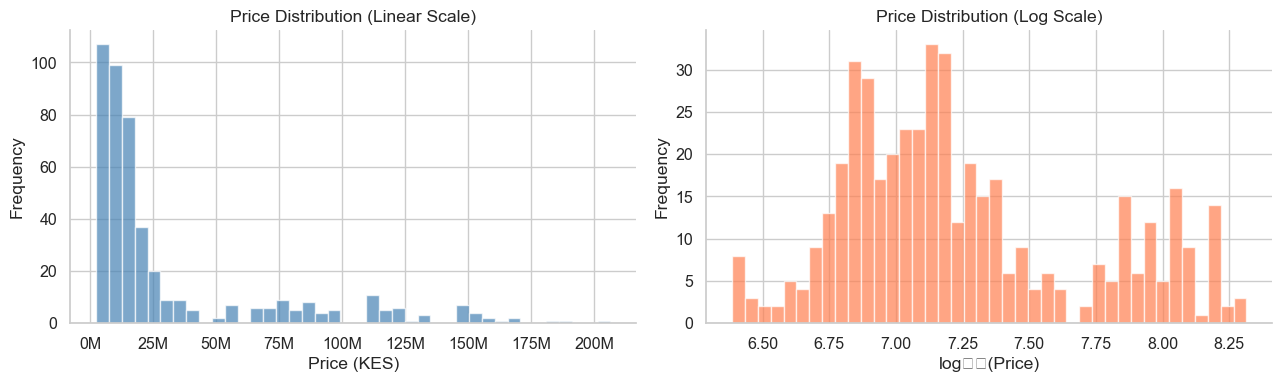

Price statistics:
count            462
mean      32,085,995
std       40,859,679
min        2,432,000
25%        8,000,000
50%       13,750,000
75%       29,300,000
max      206,418,772
Name: Price (KES), dtype: object


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 1: Distribution of Price (KES)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Histogram with KDE
axes[0].hist(df['Price (KES)'], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Price (KES)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution (Linear Scale)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Right: Log-scale histogram (better for skewed distributions)
axes[1].hist(np.log10(df['Price (KES)']), bins=40, color='coral', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('log₁₀(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f'Price statistics:')
print(df['Price (KES)'].describe().apply(lambda x: f'{x:,.0f}'))

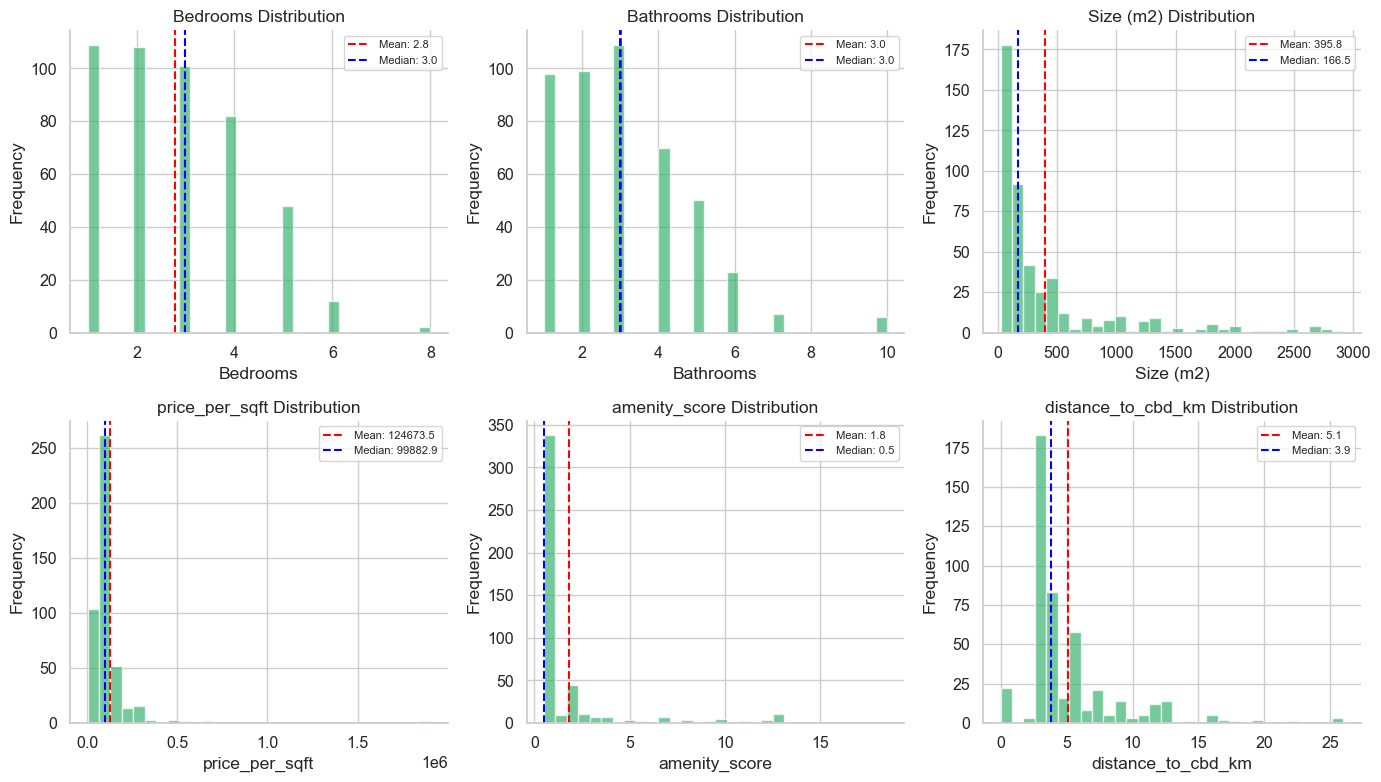

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 2: Distribution of key numeric features
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
numeric_features = ['Bedrooms', 'Bathrooms', 'Size (m2)', 'price_per_sqft', 'amenity_score', 'distance_to_cbd_km']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    ax.hist(df[col], bins=30, color='mediumseagreen', alpha=0.7, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col} Distribution')
    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

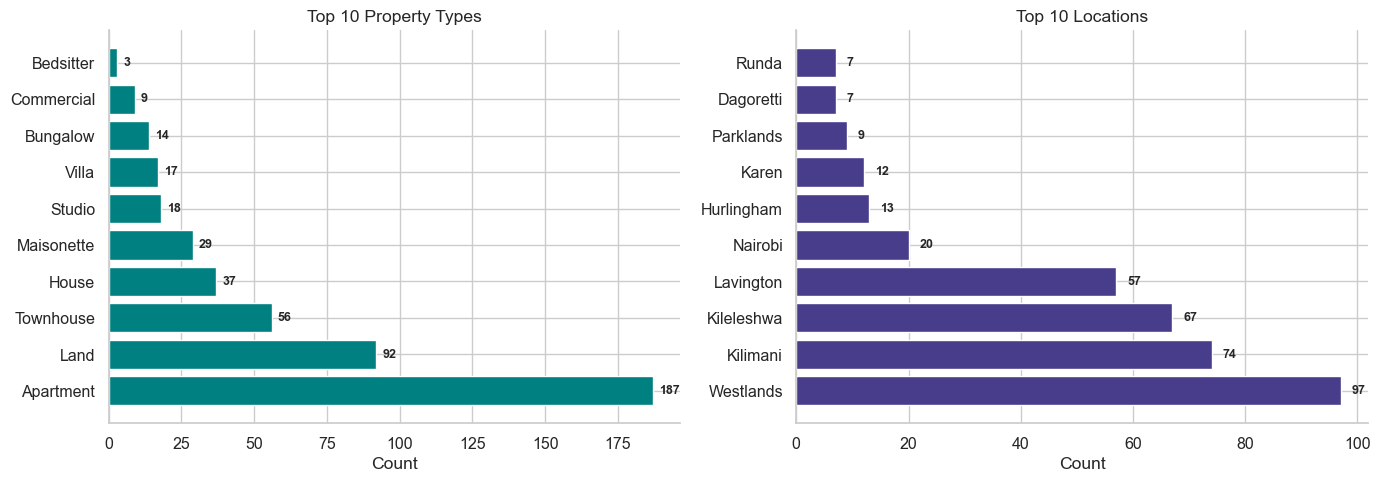

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 3: Categorical features — Property Type and Location
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Property Type
ptype_counts = df['Property Type'].value_counts().head(10)
axes[0].barh(ptype_counts.index, ptype_counts.values, color='teal', edgecolor='white')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 10 Property Types')
for i, v in enumerate(ptype_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9, fontweight='bold')

# Right: Top Locations
location_counts = df['Location'].value_counts().head(10)
axes[1].barh(location_counts.index, location_counts.values, color='darkslateblue', edgecolor='white')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 10 Locations')
for i, v in enumerate(location_counts.values):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 — Bivariate Analysis (Relationships Between Variables)

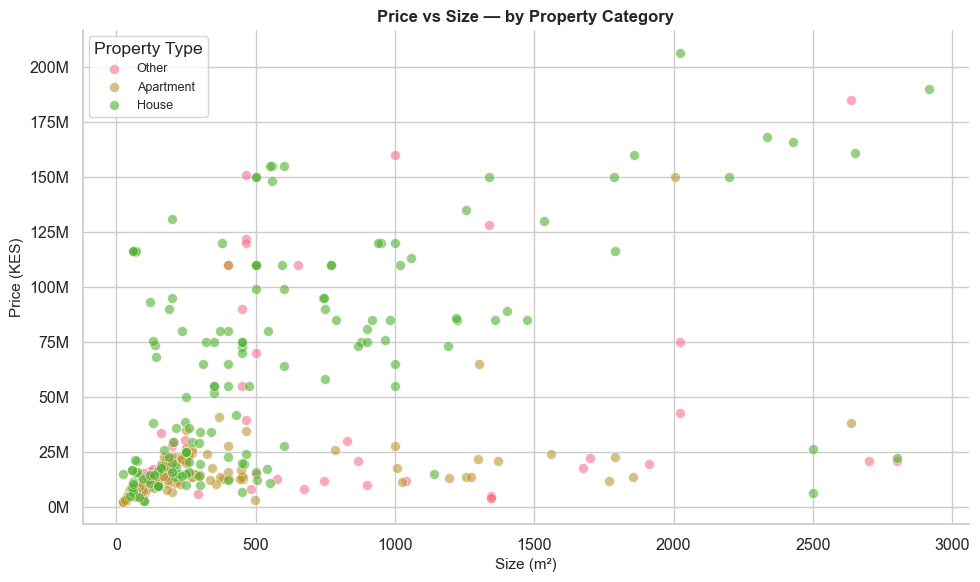

Correlation between Size and Price: 0.530  (strong positive correlation)


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 4: Price vs Size — the fundamental relationship
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot with color-coding by property category
for category in df['property_category'].unique():
    subset = df[df['property_category'] == category]
    ax.scatter(subset['Size (m2)'], subset['Price (KES)'],
               alpha=0.6, s=50, label=category, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Size (m²)', fontsize=11)
ax.set_ylabel('Price (KES)', fontsize=11)
ax.set_title('Price vs Size — by Property Category', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(title='Property Type', fontsize=9)
plt.tight_layout()
plt.show()

# Correlation coefficient
corr = df['Size (m2)'].corr(df['Price (KES)'])
print(f'Correlation between Size and Price: {corr:.3f}  (strong positive correlation)')

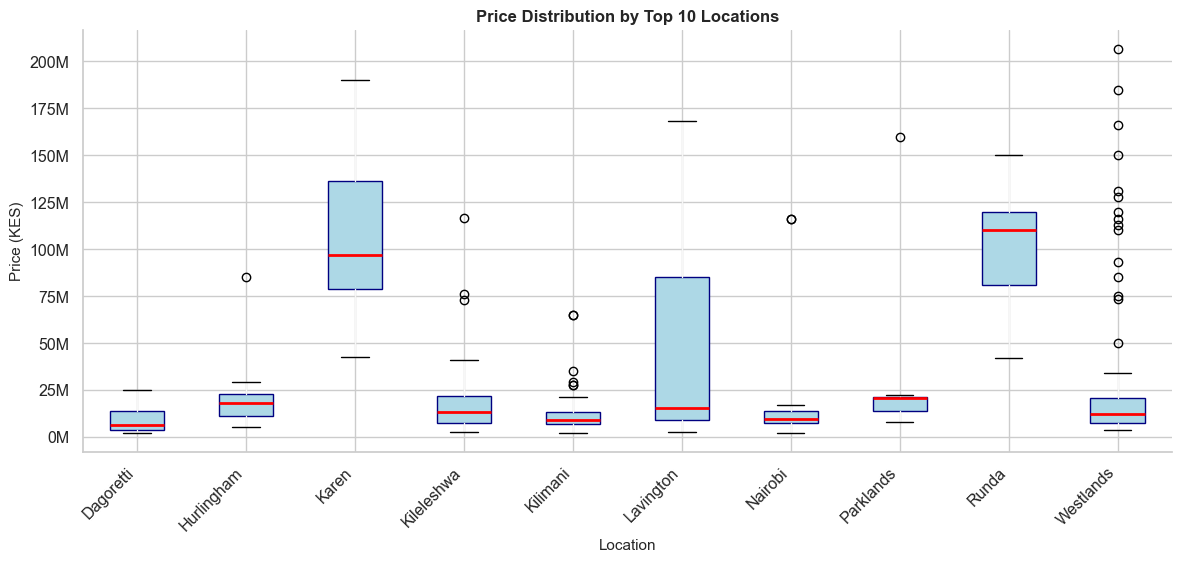

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 5: Price by Location — boxplot comparison
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Select top 10 locations by count
top_locations = df['Location'].value_counts().head(10).index
df_top_locs = df[df['Location'].isin(top_locations)]

fig, ax = plt.subplots(figsize=(12, 6))
df_top_locs.boxplot(column='Price (KES)', by='Location', ax=ax, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Location', fontsize=11)
ax.set_ylabel('Price (KES)', fontsize=11)
ax.set_title('Price Distribution by Top 10 Locations', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.xticks(rotation=45, ha='right')
plt.suptitle('')  # Remove default 'Boxplot grouped by Location' title
plt.tight_layout()
plt.show()

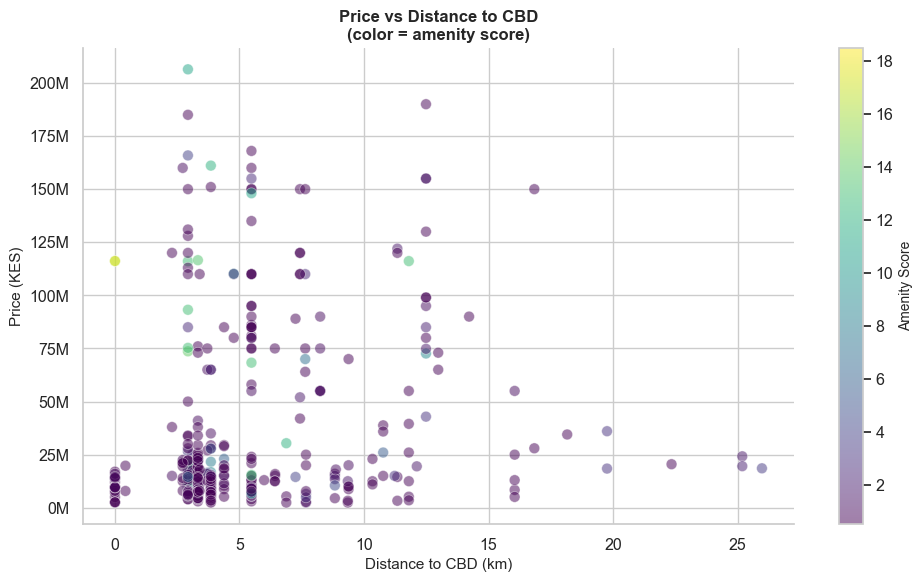

Correlation between Distance to CBD and Price: 0.206
   → Positive correlation: properties farther from CBD tend to be more expensive (suburban luxury)


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 6: Price vs Distance to CBD — geographic pricing effect
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['distance_to_cbd_km'], df['Price (KES)'],
           alpha=0.5, s=60, c=df['amenity_score'], cmap='viridis',
           edgecolors='white', linewidth=0.5)

# Add colorbar to show amenity score gradient
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Amenity Score', fontsize=10)

ax.set_xlabel('Distance to CBD (km)', fontsize=11)
ax.set_ylabel('Price (KES)', fontsize=11)
ax.set_title('Price vs Distance to CBD\n(color = amenity score)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

# Correlation
corr = df['distance_to_cbd_km'].corr(df['Price (KES)'])
print(f'Correlation between Distance to CBD and Price: {corr:.3f}')
if corr < -0.2:
    print('   → Negative correlation: properties closer to CBD tend to be more expensive')
elif corr > 0.2:
    print('   → Positive correlation: properties farther from CBD tend to be more expensive (suburban luxury)')
else:
    print('   → Weak correlation: distance to CBD is not a strong price predictor in this dataset')

### 4.3 — Correlation Matrix (Multivariate Relationships)

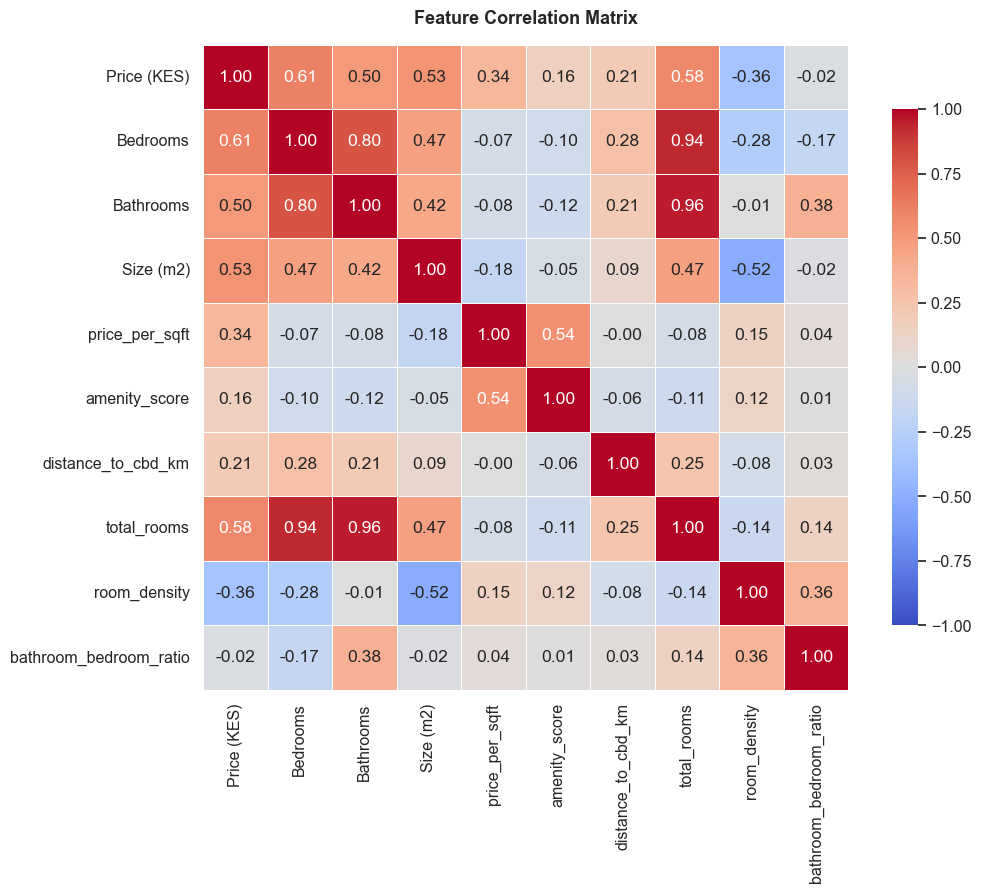


⚠️  Highly correlated feature pairs (|correlation| > 0.8):
   • Bedrooms <-> total_rooms  :  0.937
   • Bathrooms <-> total_rooms  :  0.957

   Consider removing one feature from highly correlated pairs to reduce multicollinearity.


In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VISUALIZATION 7: Correlation heatmap — identify multicollinearity
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
numeric_cols = ['Price (KES)', 'Bedrooms', 'Bathrooms', 'Size (m2)',
                'price_per_sqft', 'amenity_score', 'distance_to_cbd_km',
                'total_rooms', 'room_density', 'bathroom_bedroom_ratio']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs (potential multicollinearity)
print('\n⚠️  Highly correlated feature pairs (|correlation| > 0.8):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr:
    for feat1, feat2, corr_val in high_corr:
        print(f'   • {feat1} <-> {feat2}  :  {corr_val:.3f}')
    print('\n   Consider removing one feature from highly correlated pairs to reduce multicollinearity.')
else:
    print('   ✅ No pairs with |correlation| > 0.8 — multicollinearity is low.')

---
## 5 — Save Final Feature-Engineered Dataset

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Final dataset summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('═' * 70)
print('  DAY 2 DELIVERABLE — FEATURE-ENGINEERED DATASET')
print('═' * 70)
print(f'\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNew features created:')
print('   1. price_per_sqft           — normalized pricing metric')
print('   2. amenity_score            — quantified amenities value')
print('   3. distance_to_cbd_km       — geographic feature')
print('   4. total_rooms              — bedrooms + bathrooms')
print('   5. room_density             — rooms per m²')
print('   6. bathroom_bedroom_ratio   — luxury indicator')
print('   7. is_luxury                — binary luxury flag')
print('   8. property_category        — simplified property grouping')
print('\n✅ Dataset is model-ready.')

══════════════════════════════════════════════════════════════════════
  DAY 2 DELIVERABLE — FEATURE-ENGINEERED DATASET
══════════════════════════════════════════════════════════════════════

Final shape: 462 rows × 15 columns

Columns: ['Location', 'Property Type', 'Bedrooms', 'Bathrooms', 'Size (m2)', 'Amenities', 'Price (KES)', 'price_per_sqft', 'amenity_score', 'distance_to_cbd_km', 'total_rooms', 'room_density', 'bathroom_bedroom_ratio', 'is_luxury', 'property_category']

New features created:
   1. price_per_sqft           — normalized pricing metric
   2. amenity_score            — quantified amenities value
   3. distance_to_cbd_km       — geographic feature
   4. total_rooms              — bedrooms + bathrooms
   5. room_density             — rooms per m²
   6. bathroom_bedroom_ratio   — luxury indicator
   7. is_luxury                — binary luxury flag
   8. property_category        — simplified property grouping

✅ Dataset is model-ready.


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Save to CSV
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
output_path = 'clean_feature_listings.csv'  # Day 2 deliverable filename
df.to_csv(output_path, index=False)
print(f'\n✅ Saved to: {output_path}')
print(f'   Ready for Day 3: Model Training & Evaluation')

# Preview final dataset
df.sample(10, random_state=42)


✅ Saved to: clean_feature_listings.csv
   Ready for Day 3: Model Training & Evaluation


,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES),price_per_sqft,amenity_score,distance_to_cbd_km,total_rooms,room_density,bathroom_bedroom_ratio,is_luxury,property_category
225,Lavington,Studio,1,1,66.000000,"Swimming Pool, Gym, Garden, Parking, CCTV, SQ,...",6.750268e+06,102276.78,9.5,5.48,2,0.0303,1.0,0,Apartment
30,Lavington,Apartment,2,2,70.395948,En Suite,6.000000e+06,85232.18,0.5,5.48,4,0.0568,1.0,0,Apartment
39,Kilimani,Apartment,1,1,66.000000,En Suite,7.260000e+06,110000.00,0.5,3.85,2,0.0303,1.0,0,Apartment
222,Kileleshwa,Apartment,3,3,203.000000,"Gym, SQ",1.630236e+07,80307.21,2.5,3.33,6,0.0296,1.0,0,Apartment
124,Kilimani,Apartment,2,2,1192.000000,En Suite,1.320000e+07,11073.83,0.5,3.85,4,0.0034,1.0,0,Apartment
203,Ngong Road,Commercial,4,4,246.000000,"Swimming Pool, Gym, Parking, Security, Borehol...",3.038311e+07,123508.58,12.0,6.88,8,0.0325,1.0,0,Other
401,Parklands,Land,3,3,2700.000000,SQ,2.100000e+07,7777.78,0.5,2.72,6,0.0022,1.0,0,Other
211,Kitengela,Bungalow,3,3,456.000000,"Garden, Parking, SQ, Gate",1.957452e+07,42926.58,2.0,25.19,6,0.0132,1.0,0,House
456,Dagoretti,Townhouse,6,6,250.000000,SQ,2.500000e+07,100000.00,0.5,7.67,12,0.0480,1.0,0,House
77,Westlands,Land,1,2,60.000000,Swimming Pool,7.000000e+06,116666.67,2.0,2.93,3,0.0500,2.0,0,Other


---
## 📋 Day 2 Deliverables Checklist

✅ **clean_listings.csv** — Feature-engineered dataset  
✅ **Preprocessing notebook** — This notebook with all transformations documented  
✅ **Basic EDA visuals** — 7 key visualizations:
  1. Price distribution (linear & log scale)
  2. Numeric feature distributions
  3. Property type & location counts
  4. Price vs Size scatter
  5. Price by Location boxplot
  6. Price vs Distance to CBD
  7. Correlation heatmap

---

**Next Steps (Day 3):**
- Train baseline regression models (Linear, Random Forest, XGBoost)
- Hyperparameter tuning
- Model evaluation (RMSE, MAE, R²)
- Feature importance analysis
- Save best model for deployment